Check Scene Objects:
Objects in scene: ['no-name-3', 'Floor']
Radio Materials in scene: ['itu_concrete', 'itu_very_dry_ground']


<Figure size 800x1000 with 0 Axes>

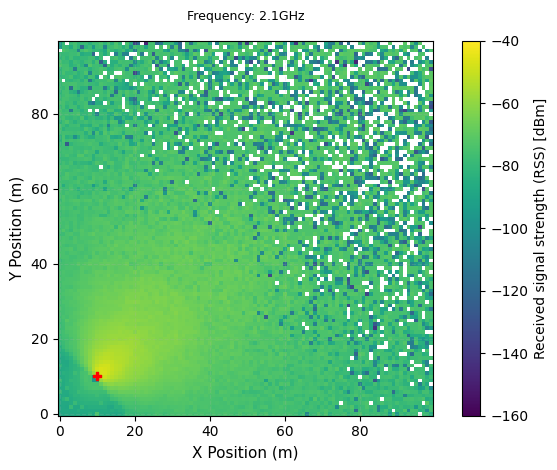


Total paths found: 984

RSS at Receiver:
RSS (Non Coherent Case): -70.18379208231066 dBm
RSS (Coherent Case): -88.27041975957468 dBm
Delta: 18.08662767726402 dB


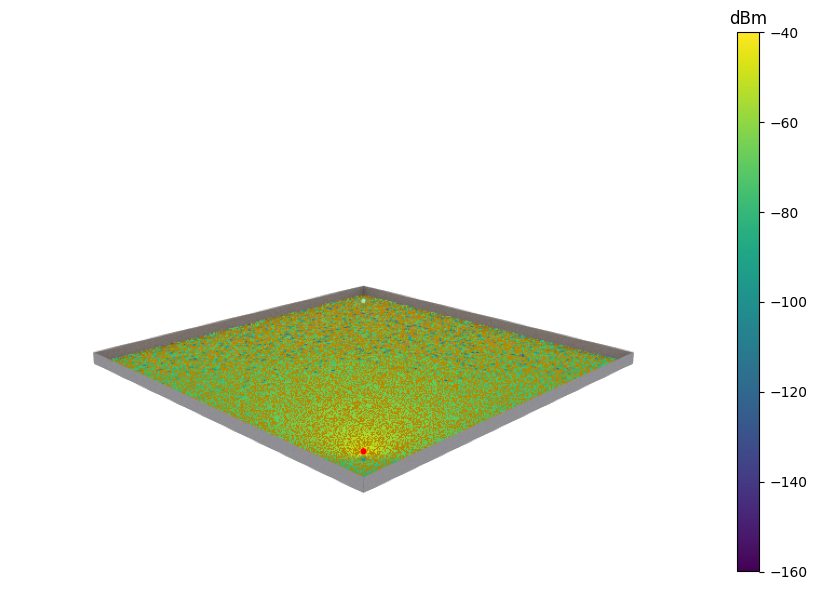

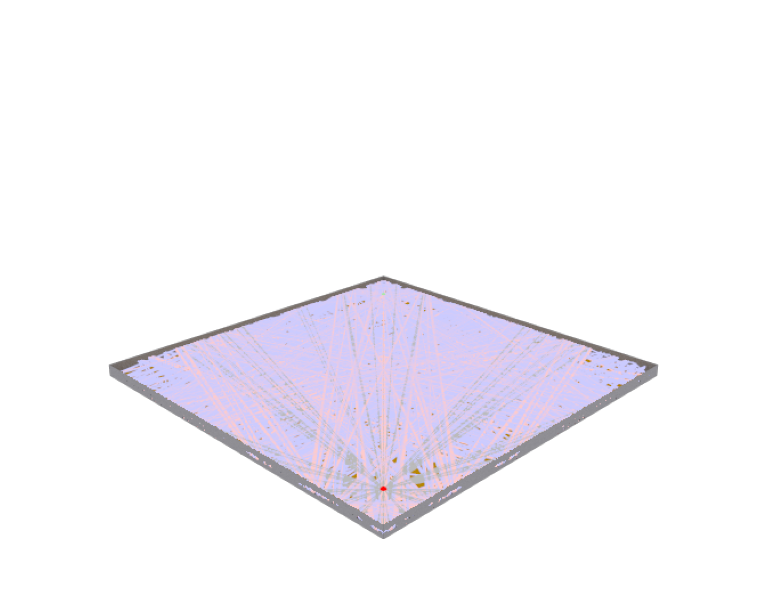

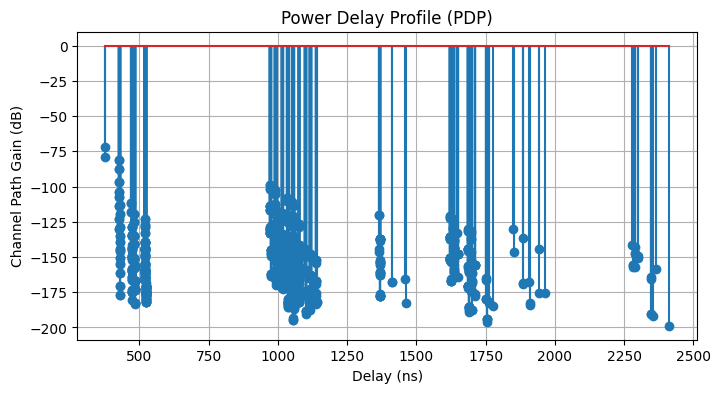

Counter({'Specular reflection': 4832, 'LOS': 2574, 'Refraction': 2434})


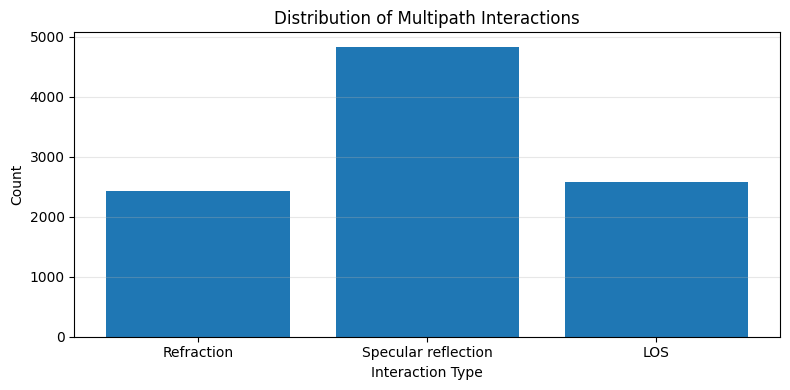

In [2]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver, InteractionType, Camera
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Import scene from blender mitsuba export (.xml)
scene = load_scene("blender-assets/empty-room/emptyroom-100x100m.xml")
# scene = load_scene("blender-assets/obstacle-room/obstacleroom-100x100m.xml")

# Check objects in the scene
print("Check Scene Objects:")
print(f"Objects in scene: {list(scene.objects.keys())}")
print(f"Radio Materials in scene: {list(scene.radio_materials.keys())}")

# Add array for both Tx and Rx to scene
scene.tx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

# Add frequency to scene
carrier_freq = 2.1e9 # In Hz
scene.frequency = carrier_freq

# Deploy Tx and Rx location
tx = Transmitter("tx", [-40, -40, 1.5], [0, 0,0], power_dbm=0)
tx_power_dbm = tx.power_dbm[0]
rx = Receiver("rx", [40, 40, 1.5], [0, 0, 0])

# Point Tx and Rx towards each other
tx.look_at(rx.position)
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Plot 2D Radio Map
rm_solver = RadioMapSolver()

rm = rm_solver(
    scene,
    max_depth=10,
    samples_per_tx=10**7,
    cell_size=(1, 1),
    center=[0, 0, 0],
    size=[100, 100],
    orientation=[0, 0, 0]
)

plt.figure(figsize=(8, 10))

rm.show(metric="rss")

plt.title(
    f"Frequency: {carrier_freq/1e9}GHz",
    fontsize=9,
    pad=15
)
plt.xlabel("X Position (m)", fontsize=11)
plt.ylabel("Y Position (m)", fontsize=11)
plt.clim(-160, -40)
plt.grid(
    alpha=0.2,
    linestyle="--"
)
plt.tight_layout()
plt.show()

# Plot 3D radio map
cam = Camera(
position=(-150, -150, 75),
look_at=rx.position
)

scene.render(
    camera=cam,
    radio_map=rm,

    rm_metric="rss",
    rm_vmax = -40,
    rm_vmin = -160,

    rm_show_color_bar=True,

    show_devices=True,
    show_orientations=True
)

# Study multipath property
# Run path solver
p_solver = PathSolver()

paths = p_solver(
    scene,
    max_depth=10,
    samples_per_src=10**6
)

# Plot 3D paths
cam = Camera(
position=(-150, -150, 100),
look_at=rx.position
)

scene.render(
    camera=cam,
    paths=paths,

)

# Extract path coefficients (a function return 2 components: a_real, a_imag)
a_real, a_imag = paths.a
a_real = a_real.numpy()
a_imag = a_imag.numpy()

# Reconstruct complex channel coefficients in real and imaginary form
a = a_real + 1j * a_imag

# Optional - Extract path delays [num_rx, num_tx, num_paths]
tau = paths.tau
if isinstance(tau, tuple):
    tau = tau[0]
tau = tau.numpy()

# a shape should return [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
# tau shape should return [num_rx, num_tx, num_paths]
# print("\nCheck a and tau shape:")
# print("a shape:", a.shape)
# print("tau shape:", tau.shape)

# Check total number of paths
num_paths = a.shape[-1]
print(f"\nTotal paths found: {num_paths}")

# Combine multipath properties into dataframe
path_data = []

for i in range(num_paths):

    # Get channel coefficient (real + imaginary) one by one
    a_coeff = a[0, 0, 0, 0, i]

    # Extract real and imaginary components
    real_coeff = np.real(a_coeff)
    imag_coeff = np.imag(a_coeff)

    # Magnitude and phase
    magnitude = np.abs(a_coeff) 
    phase_rad = np.angle(a_coeff) 

    # Channel Gain
    channel_path_gain = magnitude**2
    channel_path_gain_db = 10*np.log10(channel_path_gain)

    # Optional - Delay
    delay_s = tau[0, 0, i]
    delay_ns = delay_s * 1e9

    # Optional - Equivalent propagation distance (Free space)
    distance_m = delay_s * 3e8

    path_data.append({
        "path_id": i,
        "delay_s": float(delay_s),
        "delay_ns": float(delay_ns),
        "distance_m": float(distance_m),

        "real_coeff": float(real_coeff),
        "imag_coeff": float(imag_coeff),

        "magnitude": float(magnitude),
        "phase_rad": float(phase_rad),
        "phase_deg": float(np.degrees(phase_rad)),

        "channel_path_gain": float(channel_path_gain),
        "channel_path_gain_db": float(channel_path_gain_db),
    })

# Put array in Dataframe
df_paths = pd.DataFrame(path_data)

# Calculate Received Signal Strength (RSS) at Receivers 

# Non Coherent Case (Just a sum of power in Rx)
total_channel_path_gain = 10*np.log10(df_paths['channel_path_gain'].sum())
rss_non_coherent = tx_power_dbm+total_channel_path_gain

# Coherent Case (Consider constructive & destructive effect caused by phase delay in Rx)
total_real = df_paths['real_coeff'].sum()
total_imag = df_paths['imag_coeff'].sum()
total_magnitude = np.sqrt(total_real**2 + total_imag**2)
total_channel_path_gain = 10*np.log10(total_magnitude**2)
rss_coherent = tx_power_dbm+total_channel_path_gain

print(f"\nRSS at Receiver:")
print(f"RSS (Non Coherent Case): {rss_non_coherent} dBm")
print(f"RSS (Coherent Case): {rss_coherent} dBm")
print(f"Delta: {rss_non_coherent-rss_coherent} dB")

# Export CSV
df_paths.to_csv("output/multipath_paths_list_empty-room.csv", index=False)

# Optional - Power Delay Profile (PDP)
plt.figure(figsize=(8,4))
plt.stem(df_paths["delay_ns"], df_paths["channel_path_gain_db"])
plt.xlabel("Delay (ns)")
plt.ylabel("Channel Path Gain (dB)")
plt.title("Power Delay Profile (PDP)")
plt.grid(True)
plt.show()

# Interaction Types

interactions = paths.interactions.numpy()

counts = Counter()

for interaction in interactions.flatten():

    if interaction == InteractionType.NONE:
        counts["LOS"] += 1

    elif interaction == InteractionType.SPECULAR:
        counts["Specular reflection"] += 1

    elif interaction == InteractionType.DIFFUSE:
        counts["Diffuse reflection"] += 1

    elif interaction == InteractionType.REFRACTION:
        counts["Refraction"] += 1

    elif interaction == InteractionType.DIFFRACTION:
        counts["Diffraction"] += 1

print(counts)

plt.figure(figsize=(8,4))

plt.bar(
    counts.keys(),
    counts.values()
)

plt.xlabel("Interaction Type")
plt.ylabel("Count")
plt.title("Distribution of Multipath Interactions")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# # Optional - Scene Preview
# scene.preview()

# # Optional - Scene Preview (Radio Map)
# rm_solver = RadioMapSolver()

# rm = rm_solver(
#         scene,
#         max_depth=10, # Number of maximum interation allowed per paths
#         samples_per_tx=10**7, # Number of rays launch in transmitter
#         cell_size=(1, 1),
#         center=[0, 0, 0],
#         size=[100, 100], # Size of area to simulate (meter)
#         orientation=[0, 0, 0]
#     )

# scene.preview(
#     radio_map=rm,

#     rm_metric="rss",
#     rm_db_scale=True,

#     rm_vmax = -40,
#     rm_vmin = -160,

#     show_devices=True,
#     show_orientations=True,

#     point_picker=False
# )

# Optional - Scene Preview (Paths)
p_solver = PathSolver()

paths = p_solver(
    scene,
    max_depth=10,
    samples_per_src=10**6
)

scene.preview(
    paths=paths,

    show_devices=True,
    show_orientations=True,

    point_picker=False
)